<a href="https://colab.research.google.com/github/Lomada-Sahithi/Machine-Learning-Sem-5/blob/main/K_Nearest_Neighbors.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
import seaborn as sn
import os

In [16]:
%cd /content
!rm -rf machinelearninginaction
!git clone https://github.com/pbharrin/machinelearninginaction.git

/content
Cloning into 'machinelearninginaction'...
remote: Enumerating objects: 319, done.
remote: Total 319 (delta 0), reused 0 (delta 0), pack-reused 319 (from 1)
Receiving objects: 100% (319/319), 15.26 MiB | 14.19 MiB/s, done.
Resolving deltas: 100% (114/114), done.


In [17]:
!ls -la /content

total 20
drwxr-xr-x  1 root root 4096 Oct  3 18:31 .
drwxr-xr-x  1 root root 4096 Oct  3 18:11 ..
drwxr-xr-x  4 root root 4096 Sep 16 13:26 .config
drwxr-xr-x 17 root root 4096 Oct  3 18:31 machinelearninginaction
drwxr-xr-x  1 root root 4096 Sep 16 13:26 sample_data


In [18]:
!ls -la /content/machinelearninginaction/Ch02

total 812
drwxr-xr-x  3 root root   4096 Oct  3 18:31 .
drwxr-xr-x 17 root root   4096 Oct  3 18:31 ..
-rw-r--r--  1 root root  26067 Oct  3 18:31 datingTestSet2.txt
-rw-r--r--  1 root root  34725 Oct  3 18:31 datingTestSet.txt
-rw-r--r--  1 root root 739988 Oct  3 18:31 digits.zip
drwxr-xr-x  2 root root   4096 Oct  3 18:31 EXTRAS
-rw-r--r--  1 root root   5222 Oct  3 18:31 kNN.py
-rw-r--r--  1 root root    239 Oct  3 18:31 README.txt


In [19]:
!unzip -q -o /content/machinelearninginaction/Ch02/digits.zip -d /content/machinelearninginaction/Ch02/

In [20]:
!ls -la /content/machinelearninginaction/Ch02

total 896
drwxr-xr-x  5 root root   4096 Oct  3 18:32 .
drwxr-xr-x 17 root root   4096 Oct  3 18:31 ..
-rw-r--r--  1 root root  26067 Oct  3 18:31 datingTestSet2.txt
-rw-r--r--  1 root root  34725 Oct  3 18:31 datingTestSet.txt
-rw-r--r--  1 root root 739988 Oct  3 18:31 digits.zip
drwxr-xr-x  2 root root   4096 Oct  3 18:31 EXTRAS
-rw-r--r--  1 root root   5222 Oct  3 18:31 kNN.py
-rw-r--r--  1 root root    239 Oct  3 18:31 README.txt
drwxr-xr-x  2 root root  24576 May  4  2011 testDigits
drwxr-xr-x  2 root root  61440 May  4  2011 trainingDigits


In [21]:
import os

train_path = '/content/machinelearninginaction/Ch02/trainingDigits'
test_path  = '/content/machinelearninginaction/Ch02/testDigits'

print("Training folder exists :", os.path.exists(train_path))
print("Testing folder exists  :", os.path.exists(test_path))

train_files = os.listdir(train_path)
test_files  = os.listdir(test_path)

print(f"\nTraining files: {len(train_files)}")
print(f"Testing files : {len(test_files)}")
print(f"\nSample file names: {train_files[:5]}")

Training folder exists : True
Testing folder exists  : True

Training files: 1934
Testing files : 946

Sample file names: ['7_166.txt', '2_61.txt', '6_43.txt', '5_118.txt', '0_88.txt']


In [23]:
import numpy as np

def img_to_vector(filename):
    """Convert a 32x32 text image into a 1x1024 vector."""
    return_vec = np.zeros((1, 1024))
    with open(filename) as f:
        for i in range(32):
            line = f.readline()
            for j in range(32):
                return_vec[0, 32*i + j] = int(line[j])
    return return_vec

In [24]:
import os

def load_data(folder_path):
    """Load all files from a folder and return feature matrix X and label vector y."""
    files = os.listdir(folder_path)
    m = len(files)
    X = np.zeros((m, 1024))
    y = np.zeros(m)
    for i, file in enumerate(files):
        y[i] = int(file.split('_')[0])          # label = first char of filename
        X[i, :] = img_to_vector(os.path.join(folder_path, file))
    return X, y

In [25]:
X_train, y_train = load_data('/content/machinelearninginaction/Ch02/trainingDigits')
X_test,  y_test  = load_data('/content/machinelearninginaction/Ch02/testDigits')

print("Training set shape:", X_train.shape)
print("Training labels shape:", y_train.shape)
print("Testing set shape:", X_test.shape)
print("Testing labels shape:", y_test.shape)

Training set shape: (1934, 1024)
Training labels shape: (1934,)
Testing set shape: (946, 1024)
Testing labels shape: (946,)


In [26]:
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(n_neighbors=3, metric='minkowski', p=2)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("First 30 predictions :", y_pred[:30].astype(int))
print("First 30 true labels :", y_test[:30].astype(int))

First 30 predictions : [2 6 5 2 2 5 0 7 3 4 5 0 4 0 3 1 5 4 2 9 1 2 9 9 4 0 7 0 8 8]
First 30 true labels : [2 6 5 2 2 5 0 7 3 4 5 0 4 0 3 1 5 4 2 9 1 2 9 9 4 0 7 0 8 8]


In [27]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

Accuracy_score = accuracy_score(y_test, y_pred)
print("KNN [minkowski] with n_neighbor = 3")
print("=" * 60)
print("Accuracy Score:", Accuracy_score)
print("Accuracy in Percentage:", round(Accuracy_score * 100, 2), "%")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

KNN [minkowski] with n_neighbor = 3
Accuracy Score: 0.9883720930232558
Accuracy in Percentage: 98.84 %

Classification Report:

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        87
         1.0       0.96      0.99      0.97        97
         2.0       1.00      1.00      1.00        92
         3.0       0.98      0.99      0.98        85
         4.0       1.00      1.00      1.00       114
         5.0       1.00      0.98      0.99       108
         6.0       0.98      1.00      0.99        87
         7.0       0.98      1.00      0.99        96
         8.0       1.00      0.95      0.97        91
         9.0       0.99      0.98      0.98        89

    accuracy                           0.99       946
   macro avg       0.99      0.99      0.99       946
weighted avg       0.99      0.99      0.99       946



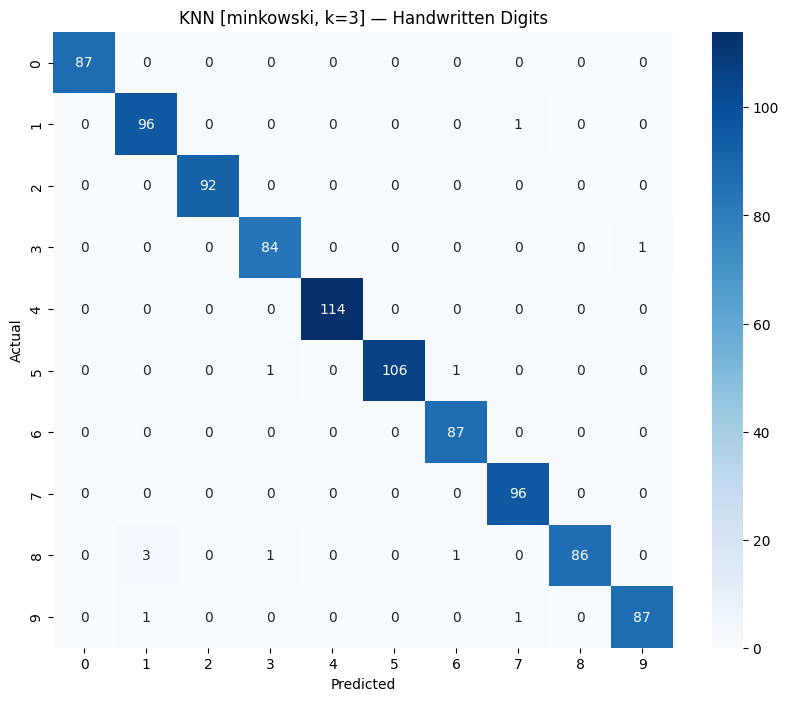

In [28]:
import matplotlib.pyplot as plt
import seaborn as sn

plt.figure(figsize=(10, 8))
sn.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
           xticklabels=range(10), yticklabels=range(10))
plt.title('KNN [minkowski, k=3] — Handwritten Digits')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [29]:
results = []
for i in [1, 2, 3, 4, 5, 7, 9]:
    model = KNeighborsClassifier(n_neighbors=i, metric='minkowski', p=2)
    model.fit(X_train, y_train)
    y_pred_i = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred_i)
    results.append(acc)
    print(f"k={i}: Accuracy = {acc:.4f} ({acc*100:.2f}%)")

k=1: Accuracy = 0.9873 (98.73%)
k=2: Accuracy = 0.9767 (97.67%)
k=3: Accuracy = 0.9884 (98.84%)
k=4: Accuracy = 0.9831 (98.31%)
k=5: Accuracy = 0.9810 (98.10%)
k=7: Accuracy = 0.9767 (97.67%)
k=9: Accuracy = 0.9736 (97.36%)


True Label      : 3
Predicted Label : 3
Match           : ✅ Correct


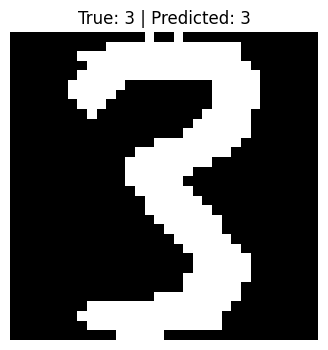

In [30]:
import random
random.seed(7)
idx = random.randint(0, len(X_test) - 1)

# Treat this sample as a "new" handwritten specimen
new_digit = X_test[idx].reshape(1, -1)
true_label = int(y_test[idx])

# Use the best model (k=3)
best_model = KNeighborsClassifier(n_neighbors=3, metric='minkowski', p=2)
best_model.fit(X_train, y_train)
predicted_label = best_model.predict(new_digit)[0]

print(f"True Label      : {true_label}")
print(f"Predicted Label : {int(predicted_label)}")
print(f"Match           : {'✅ Correct' if true_label == predicted_label else '❌ Wrong'}")

# Show the actual image
plt.figure(figsize=(4, 4))
plt.imshow(X_test[idx].reshape(32, 32), cmap='gray')
plt.title(f"True: {true_label} | Predicted: {int(predicted_label)}")
plt.axis('off')
plt.show()

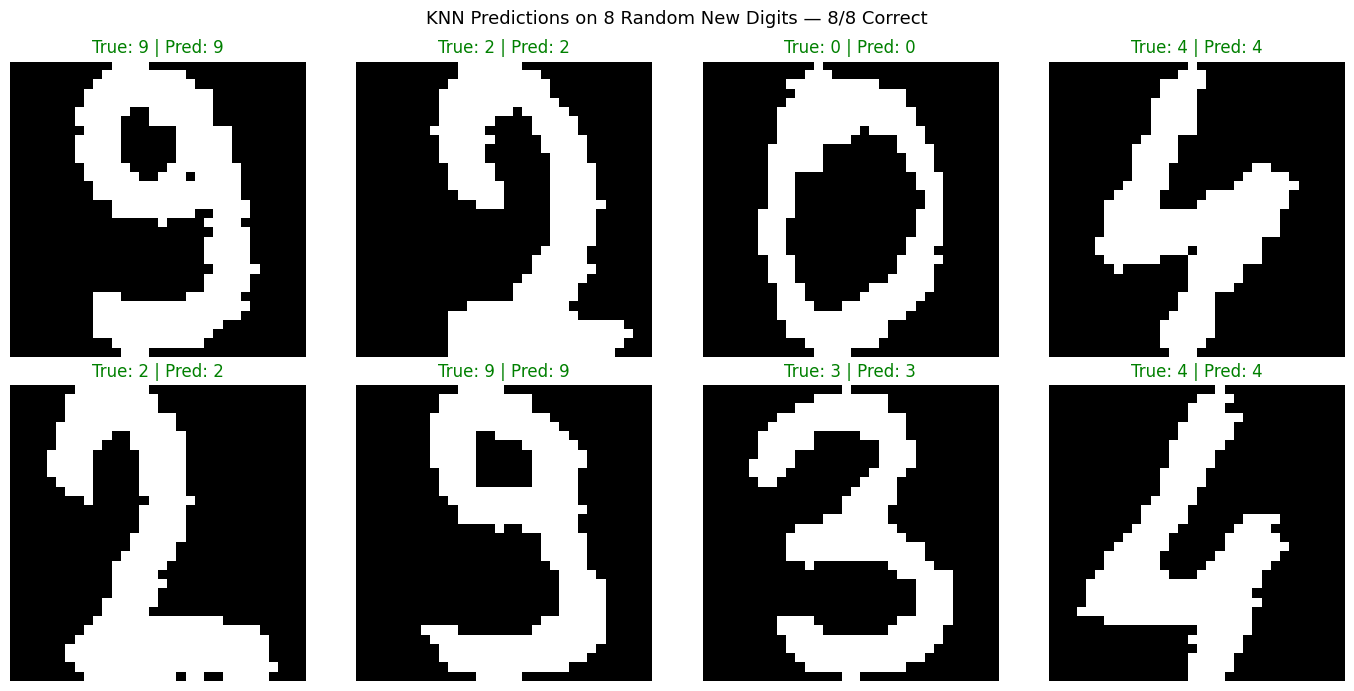

In [31]:
import random
random.seed(42)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
indices = random.sample(range(len(X_test)), 8)

correct_count = 0
for i, idx in enumerate(indices):
    new_digit = X_test[idx].reshape(1, -1)
    true_label = int(y_test[idx])
    predicted_label = int(best_model.predict(new_digit)[0])

    if true_label == predicted_label:
        correct_count += 1

    ax = axes[i // 4, i % 4]
    ax.imshow(X_test[idx].reshape(32, 32), cmap='gray')
    color = 'green' if true_label == predicted_label else 'red'
    ax.set_title(f"True: {true_label} | Pred: {predicted_label}", color=color)
    ax.axis('off')

plt.suptitle(f'KNN Predictions on 8 Random New Digits — {correct_count}/8 Correct', fontsize=13)
plt.tight_layout()
plt.show()

In [32]:
import pandas as pd

k_vals = [1, 2, 3, 4, 5, 7, 9]
models_summary = pd.DataFrame({
    'n_neighbors': k_vals,
    'Accuracy Score': results
})
models_summary = models_summary.sort_values(by='Accuracy Score', ascending=False)
print(models_summary.to_string(index=False))

 n_neighbors  Accuracy Score
           3        0.988372
           1        0.987315
           4        0.983087
           5        0.980973
           2        0.976744
           7        0.976744
           9        0.973573
